In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from PIL import Image
from google.cloud import vision

# 1. Define a local folder for models
# cache_dir = "./model_cache"
# os.makedirs(cache_dir, exist_ok=True)

# 2. Tell Hugging Face to use this folder
# os.environ['HF_HOME'] = cache_dir
# os.environ['TRANSFORMERS_CACHE'] = cache_dir

# 3. It is recommended to make the following changes using terminal instead of code
# The reason behind this is, if the json key is used here in the code, 
# it is not safe, as the code might be shared between individual.
# export GOOGLE_APPLICATION_CREDENTIALS="/path/to/your/keys/service-account-key.json"

# Otherwise, use the following the inside this code:
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"/path/to/your/keys/service-account-key.json"

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BlipProcessor, BlipForConditionalGeneration

from tqdm.notebook import tqdm

In [3]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-9o9pq7gd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-9o9pq7gd
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=637fd62c63d97c2fb0042158483db5675594342eb960132ab6d2d6878c5d187f
  Stored in directory: /tmp/pip-ephem-wheel-cache-fs2wmcei/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import clip

In [5]:
# --- CONFIGURATION ---
# UPDATE THESE PATHS TO YOUR LOCAL PATHS
TEXT_MODEL_NAME = "t5-base"  # Or your specific fine-tuned path
BLIP_MODEL_NAME = "Salesforce/blip-image-captioning-base"
CLIP_MODEL_NAME = "ViT-B/32"
CLIP_WEIGHTS_PATH = "/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt" # Update this
TEXT_WEIGHTS_PATH = "/kaggle/input/best-models-musait/TSA/T5__best_model.pt" # Update this

MAX_LENGTH = 128
SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0: 'Negative', 1: 'Neutral', 2: "Positive"}

csv_filepath = "/kaggle/input/musait/MUSAIT__all_info_uniques.csv"
df = pd.read_csv(csv_filepath)
all_filenames = df["filename"]
all_ocr = df["OCR"]

In [6]:
# --- CLIP CLASSIFIER WRAPPER ---
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()
        return self.classifier(x)

# --- MODEL LOADER ---
def load_core_models():
    """
    Loads all models onto the device once to be cached by Streamlit.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading models on {device}...")

    # 1. Load BLIP (Captioning)
    blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
    blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME).to(device)

    # 2. Load Text Model (DistilRoBERTa/T5)
    # Note: Ensure num_labels matches your training (e.g., 3 for Neg/Neu/Pos)
    text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
    text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_NAME, num_labels=3)
    
    # Load weights if they exist, otherwise use base (warning: base model won't predict sentiment correctly without fine-tuning)
    if os.path.exists(TEXT_WEIGHTS_PATH):
        text_model.load_state_dict(torch.load(TEXT_WEIGHTS_PATH, map_location=device))
    text_model.to(device)
    text_model.eval()

    # 3. Load CLIP (Visual)
    # clip_path = os.path.join(cache_dir, "ViT-B-32.pt")
    clip_base, image_preprocess = clip.load(CLIP_MODEL_NAME, device=device)
    # We need the embed_dim from the visual part of CLIP (usually 512 for ViT-B/32)
    embed_dim = clip_base.visual.output_dim 
    
    image_model = CLIPClassifier(clip_base.visual, embed_dim=embed_dim, num_classes=3).to(device)
    if os.path.exists(CLIP_WEIGHTS_PATH):
        image_model.load_state_dict(torch.load(CLIP_WEIGHTS_PATH, map_location=device))
    image_model.eval()

    return {
        "device": device,
        "blip_processor": blip_processor,
        "blip_model": blip_model,
        "text_tokenizer": text_tokenizer,
        "text_model": text_model,
        "image_preprocess": image_preprocess,
        "image_model": image_model
    }

# --- HELPER: GOOGLE VISION OCR ---
def get_ocr_text(image_content):
    """
    Performs OCR using Google Vision API.
    """
    client = vision.ImageAnnotatorClient()
    image = vision.Image(content=image_content)
    response = client.text_detection(image=image)
    texts = response.text_annotations
    
    if texts:
        # texts[0] is the full text, subsequent indices are words
        return texts[0].description, texts[0] 
    return None, None
 
 
def check_text_detection_v1(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False


def check_text_detection_v2(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts if texts else False


# --- HELPER: ALPHA CALCULATION (Simplified v1) ---
def calculate_alpha(ocr_annotation, img_width, img_height):
    """
    Calculates the area of text relative to image area.
    """
    if not ocr_annotation:
        return 0.5 # Default if no text found via OCR

    img_area = img_width * img_height
    
    # Calculate bounding box of the full text
    vertices = ocr_annotation.bounding_poly.vertices
    x_values = [v.x for v in vertices]
    y_values = [v.y for v in vertices]
    
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)
    
    txt_area = txt_width * txt_height
    alpha = txt_area / img_area
    
    # Clip alpha to reasonable bounds (e.g., don't let it be 0 or 1 purely based on size)
    return min(max(alpha, 0.2), 0.8)
    

def get_alpha_v1(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    return txt_weightage
    

def get_alpha_v2(texts, img_area):
   total_text_area = 0
   for t in texts[1:]:
       vertices = [(v.x, v.y) for v in t.bounding_poly.vertices]
       text_area = polygon_area(vertices)
       total_text_area += text_area
       print(f"Word: {t.description}, Area: {text_area}")
   
   print("Total Area:", total_text_area)
   alpha = total_text_area/img_area
   return alpha

# --- MAIN INFERENCE PIPELINE (MeVITSA) ---
def mevitsa_analysis(image_filename, image_pil, image_bytes, models_dict, manual_alpha=None, gcv_api=1, ft=1):
    """
    The MeVITSA Method:
    1. Extract Text (OCR from CSV) -> if failed, Generate Caption (BLIP).
    2. Get Text Sentiment (T5).
    3. Get Image Sentiment (CLIP).
    4. Fuse using Alpha (Area-based or Manual).
    """
    flag = 0 # flags the image having NO TEXT.
    device = models_dict["device"]
    # print("Here")
    # 1. VISUAL PIPELINE
    # ------------------
    image_tensor = models_dict["image_preprocess"](image_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        visual_logits = models_dict["image_model"](image_tensor)
        visual_probs = F.softmax(visual_logits, dim=1).cpu().numpy().flatten()
    # print("Here")
    # 2. TEXT PIPELINE
    # ----------------
    ocr_text = ""
    final_text = ""
    source = "BLIP" # Default source
    
    if gcv_api==1:
        ocr_text, ocr_annotation = get_ocr_text(image_bytes)
        source = "OCR"
        final_text = ocr_text
    else:
		# Check if image exists in the CSV data
		# Note: using .values ensures we check the content, not the index
        if image_filename in all_filenames.values:
            matched_row = df.loc[df["filename"] == image_filename].iloc[0]
            ocr_text = matched_row["OCR"]
            # Logic: If OCR exists and is not empty/NaN, use it. Otherwise, use BLIP.
            if pd.notna(ocr_text) and str(ocr_text).strip() != "":
                final_text = str(ocr_text)
                source = "OCR"
            else:
                flag = 1
                if ft==1:
                    # Fault Tolerance: Generate Caption via BLIP
                    source = "BLIP"
                    inputs = models_dict["blip_processor"](images=image_pil, return_tensors="pt").to(device)
                    out = models_dict["blip_model"].generate(**inputs)
                    # print(out)
                    # print(out[0])
                    final_text = models_dict["blip_processor"].decode(out[0], skip_special_tokens=True)
                    # print("Here")
                else:
                    final_text = ""
    
    # Tokenize and Predict
    inputs = models_dict["text_tokenizer"](
        final_text, 
        return_tensors="pt", 
        truncation=True, 
        padding=True, 
        max_length=MAX_LENGTH
    ).to(device)
    # print("Here")
    with torch.no_grad():
        text_outputs = models_dict["text_model"](**inputs)
        text_probs = F.softmax(text_outputs.logits, dim=1).cpu().numpy().flatten()
    # print("Here")
    # 3. FUSION (MeVITSA LOGIC)
    # ----------------------
    if manual_alpha is not None:
        alpha = manual_alpha
    else:
        # Note: Since we are reading from CSV, we might not have 'ocr_annotation' 
        # for area calculation unless it's also saved in the CSV. 
        # For now, we default to 0.5 if using BLIP or if area data is missing.
        alpha = 0.5 
    
    # Weighted Average
    final_probs = (alpha * text_probs) + ((1 - alpha) * visual_probs)
    pred_idx = np.argmax(final_probs)
    # print("Here")
    return {
        "final_class": LABELS_TO_SENTIMENTS[pred_idx],
        "final_probs": final_probs,
        "text_probs": text_probs,
        "visual_probs": visual_probs,
        "text_content": final_text,
        "text_source": source,
        "alpha_used": alpha,
        "flag": flag
    }

In [7]:
# ---------------- CONFIGURATION ----------------
# Path to your image folder
DATASET_FOLDER = "/kaggle/input/musait/basket_unique" 

# Ensure models are loaded
# if 'models' not in locals():
print("Loading models...")
models = load_core_models()

Loading models...
Loading models on cuda...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

T5ForSequenceClassification LOAD REPORT from: t5-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 40.9MiB/s]


In [8]:
# ---------------- HELPER: PARSE LABEL ----------------
def get_true_label(filename):
    """
    Parses sentiment from filename.
    Assumes format like: 'positive_123.jpg' or '123_negative.jpg'
    """
    filename_lower = filename.lower()
    if "positive" in filename_lower:
        return "Positive"
    elif "negative" in filename_lower:
        return "Negative"
    elif "neutral" in filename_lower:
        return "Neutral"
    return None

In [9]:
# ---------------- MAIN ANALYSIS LOOP ----------------
valid_extensions = ('.jpg', '.jpeg', '.png', ".JPG")
image_files = [f for f in os.listdir(DATASET_FOLDER) if f.lower().endswith(valid_extensions)]

print(f"Found {len(image_files)} images. Starting analysis...")

Found 2054 images. Starting analysis...


In [10]:
results = []
count = 0
for img_name in tqdm(image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    
    # 1. Get Ground Truth
    true_label = get_true_label(img_name)
    if not true_label:
        continue # Skip if no label found in filename
    # print("here")
    # 2. Prepare Image
    try:
        image_pil = Image.open(img_path).convert("RGB")
        # specific to your pipeline: needs bytes for OCR check (if using API)
        # or filename lookup if relying on CSV
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        # print("here")
        # 3. Run MeViTSA Inference
        # Note: We pass img_name because your model looks it up in the CSV for OCR
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=0 # 0 for disabled and 1 for enabled
        )
        # print("here")
        # if prediction['text_source']=="BLIP":
        #     print(prediction['text_content'])
        # 4. Log Data
        results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content'] # [:50] + "..." # Truncate for display
        })
        count += prediction['flag']
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")
    # print(results)
    # break


print(f"Number of images having no text: {count}")

  0%|          | 0/2054 [00:00<?, ?it/s]

Number of images having no text: 108


## With TEF component disabled

In [11]:
disabled_results = []
count = 0
for img_name in tqdm(image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    
    # 1. Get Ground Truth
    true_label = get_true_label(img_name)
    if not true_label:
        continue # Skip if no label found in filename
    # print("here")
    # 2. Prepare Image
    try:
        image_pil = Image.open(img_path).convert("RGB")
        # specific to your pipeline: needs bytes for OCR check (if using API)
        # or filename lookup if relying on CSV
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        # print("here")
        # 3. Run MeViTSA Inference
        # Note: We pass img_name because your model looks it up in the CSV for OCR
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=0 # 0 for disabled and 1 for enabled
        )
        # print("here")
        # if prediction['text_source']=="BLIP":
        #     print(prediction['text_content'])
        # 4. Log Data
        disabled_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content'] # [:50] + "..." # Truncate for display
        })
        count += prediction['flag']
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")
    # print(results)
    # break


print(f"Number of images having no text: {count}")

  0%|          | 0/2054 [00:00<?, ?it/s]

Number of images having no text: 108



✅ Overall Accuracy: 95.6183%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9854    0.9381    0.9611       646
     Neutral     0.9036    0.9863    0.9431       656
    Positive     0.9834    0.9455    0.9641       752

    accuracy                         0.9562      2054
   macro avg     0.9575    0.9566    0.9561      2054
weighted avg     0.9585    0.9562    0.9565      2054



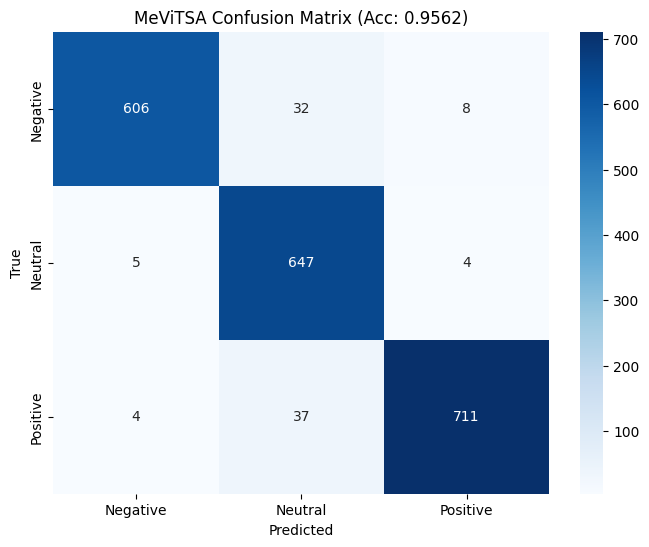

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- METRICS & VISUALIZATION ----------------
df_results = pd.DataFrame(disabled_results)
output_path = "mevitsa_results_ft0.csv"
df_results.to_csv(output_path, index=False)

# 1. Basic Accuracy
acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

# 2. Classification Report
print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_ft0__confusion_matrix.png")
plt.show()

## With TEF component enabled

In [13]:
enabled_results = []
count = 0
for img_name in tqdm(image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    
    # 1. Get Ground Truth
    true_label = get_true_label(img_name)
    if not true_label:
        continue # Skip if no label found in filename
    # print("here")
    # 2. Prepare Image
    try:
        image_pil = Image.open(img_path).convert("RGB")
        # specific to your pipeline: needs bytes for OCR check (if using API)
        # or filename lookup if relying on CSV
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        # print("here")
        # 3. Run MeViTSA Inference
        # Note: We pass img_name because your model looks it up in the CSV for OCR
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=1 # 0 for disabled and 1 for enabled
        )
        # print("here")
        # if prediction['text_source']=="BLIP":
        #     print(prediction['text_content'])
        # 4. Log Data
        enabled_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content'] # [:50] + "..." # Truncate for display
        })
        count += prediction['flag']
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")
    # print(results)
    # break


print(f"Number of images having no text: {count}")

  0%|          | 0/2054 [00:00<?, ?it/s]

Number of images having no text: 108



✅ Overall Accuracy: 95.9591%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9748    0.9567    0.9656       646
     Neutral     0.9198    0.9787    0.9483       656
    Positive     0.9848    0.9455    0.9647       752

    accuracy                         0.9596      2054
   macro avg     0.9598    0.9603    0.9595      2054
weighted avg     0.9609    0.9596    0.9598      2054



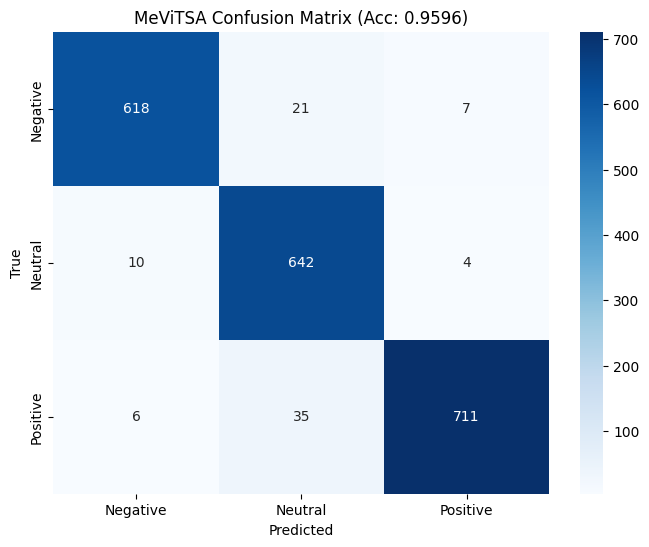

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- METRICS & VISUALIZATION ----------------
df_results = pd.DataFrame(enabled_results)
output_path = "mevitsa_results_ft1.csv"
df_results.to_csv(output_path, index=False)

# 1. Basic Accuracy
acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

# 2. Classification Report
print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_ft1__confusion_matrix.png")
plt.show()

# Subset: ***NO TEXT***

In [15]:
df.head()

,Unnamed: 0,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,0,negative_001.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,1,negative_002.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,2,negative_003.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,3,negative_004.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
4,4,negative_006.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BR...,"[{'x': 62, 'y': 28}, {'x': 641, 'y': 28}, {'x'...",16:9,horizontal,292320,16:9,horizontal,172542,0.590250,negative


In [16]:
subset = df[df['text-detected']==0]
subset

,Unnamed: 0,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
2,2,negative_003.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.0,negative
3,3,negative_004.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.0,negative
7,7,negative_009.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],16:9,horizontal,50232,NaN,NaN,0,0.0,negative
10,10,negative_013.jpg,/kaggle/input/musait/basket_unique/negative_01...,0,NaN,[],Other,other,50575,NaN,NaN,0,0.0,negative
11,11,negative_014.jpg,/kaggle/input/musait/basket_unique/negative_01...,0,NaN,[],3:2,horizontal,50478,NaN,NaN,0,0.0,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,1440,positive_153.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1441,1441,positive_156.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1444,1444,positive_159.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1446,1446,positive_161.jpg,/kaggle/input/musait/basket_unique/positive_16...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive


## w/  TEF

In [17]:
subset_image_files = [fpath for fpath in subset['filename']]
subset_results = []

In [18]:
for img_name in tqdm(subset_image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    true_label = get_true_label(img_name)
    
    if not true_label:
        continue
    
    try:
        image_pil = Image.open(img_path).convert("RGB")
        
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=1
        )
        
        subset_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content']
        })
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

  0%|          | 0/108 [00:00<?, ?it/s]


✅ Overall Accuracy: 62.9630%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.8182    0.8182    0.8182        44
     Neutral     0.4754    0.8529    0.6105        34
    Positive     1.0000    0.1000    0.1818        30

    accuracy                         0.6296       108
   macro avg     0.7645    0.5904    0.5368       108
weighted avg     0.7608    0.6296    0.5760       108



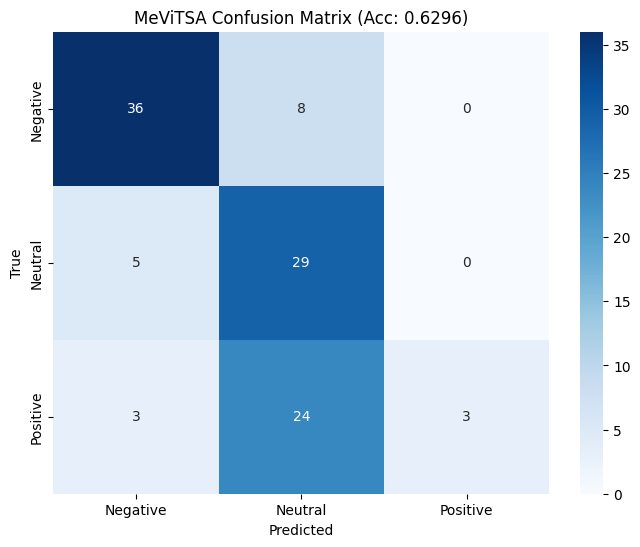

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(subset_results)
output_path = "mevitsa_subset_results_ft1.csv"
df_results.to_csv(output_path, index=False)

acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_subset_ft1__confusion_matrix.png")
plt.show()

## w/o TEF

In [20]:
subset_image_files = [fpath for fpath in subset['filename']]
subset_disabled_results = []

In [21]:
for img_name in tqdm(subset_image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    true_label = get_true_label(img_name)
    
    if not true_label:
        continue
    
    try:
        image_pil = Image.open(img_path).convert("RGB")
        
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=0
        )
        
        subset_disabled_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content']
        })
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

  0%|          | 0/108 [00:00<?, ?it/s]


✅ Overall Accuracy: 56.4815%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9600    0.5455    0.6957        44
     Neutral     0.4304    1.0000    0.6018        34
    Positive     0.7500    0.1000    0.1765        30

    accuracy                         0.5648       108
   macro avg     0.7135    0.5485    0.4913       108
weighted avg     0.7349    0.5648    0.5219       108



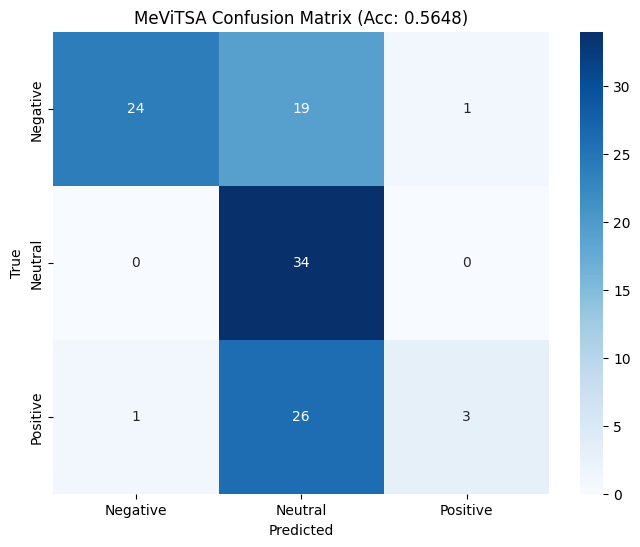

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(subset_disabled_results)
output_path = "mevitsa_subset_results_ft0.csv"
df_results.to_csv(output_path, index=False)

acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_subset_ft0__confusion_matrix.png")
plt.show()

In [23]:
subset

,Unnamed: 0,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
2,2,negative_003.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.0,negative
3,3,negative_004.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.0,negative
7,7,negative_009.jpg,/kaggle/input/musait/basket_unique/negative_00...,0,NaN,[],16:9,horizontal,50232,NaN,NaN,0,0.0,negative
10,10,negative_013.jpg,/kaggle/input/musait/basket_unique/negative_01...,0,NaN,[],Other,other,50575,NaN,NaN,0,0.0,negative
11,11,negative_014.jpg,/kaggle/input/musait/basket_unique/negative_01...,0,NaN,[],3:2,horizontal,50478,NaN,NaN,0,0.0,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,1440,positive_153.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1441,1441,positive_156.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1444,1444,positive_159.jpg,/kaggle/input/musait/basket_unique/positive_15...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive
1446,1446,positive_161.jpg,/kaggle/input/musait/basket_unique/positive_16...,0,NaN,[],1:1,box,65536,NaN,NaN,0,0.0,positive


# Subset: ***Has TEXT***

In [24]:
large_subset = df[df['text-detected']==1]
large_subset_image_files = [fpath for fpath in large_subset['filename']]

In [25]:
len(large_subset_image_files)

1946

## w/o TEF

In [26]:
large_subset_disabled_results = []

for img_name in tqdm(large_subset_image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    true_label = get_true_label(img_name)
    
    if not true_label:
        continue
    
    try:
        image_pil = Image.open(img_path).convert("RGB")
        
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=0
        )
        
        large_subset_disabled_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content']
        })
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

  0%|          | 0/1946 [00:00<?, ?it/s]

In [27]:
len(large_subset_disabled_results)

1946


✅ Overall Accuracy: 97.7903%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9864    0.9668    0.9765       602
     Neutral     0.9623    0.9855    0.9738       622
    Positive     0.9847    0.9806    0.9827       722

    accuracy                         0.9779      1946
   macro avg     0.9778    0.9776    0.9776      1946
weighted avg     0.9781    0.9779    0.9779      1946



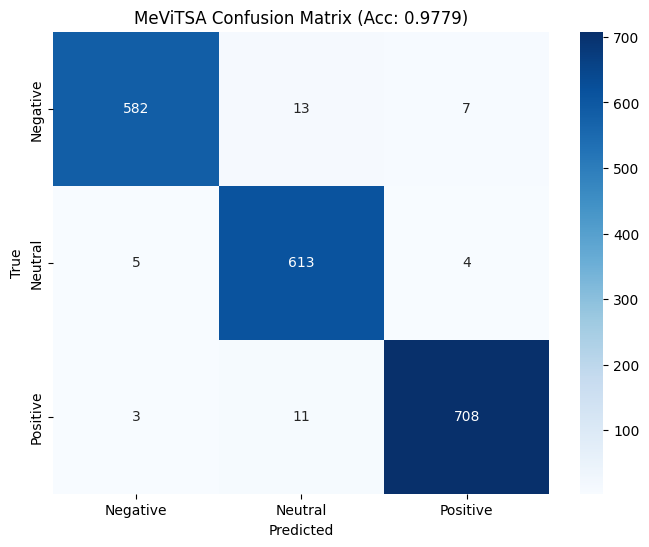

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(large_subset_disabled_results)
output_path = "mevitsa_large_subset_results_TEF0.csv"
df_results.to_csv(output_path, index=False)

acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_large_subset_TEF0__confusion_matrix.png")
plt.show()

## w/ TEF

In [29]:
large_subset_enabled_results = []

for img_name in tqdm(large_subset_image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    true_label = get_true_label(img_name)
    
    if not true_label:
        continue
    
    try:
        image_pil = Image.open(img_path).convert("RGB")
        
        with open(img_path, "rb") as f:
            image_bytes = f.read()
        
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0,
            ft=1
        )
        
        large_subset_enabled_results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content']
        })
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

  0%|          | 0/1946 [00:00<?, ?it/s]


✅ Overall Accuracy: 97.7903%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9864    0.9668    0.9765       602
     Neutral     0.9623    0.9855    0.9738       622
    Positive     0.9847    0.9806    0.9827       722

    accuracy                         0.9779      1946
   macro avg     0.9778    0.9776    0.9776      1946
weighted avg     0.9781    0.9779    0.9779      1946



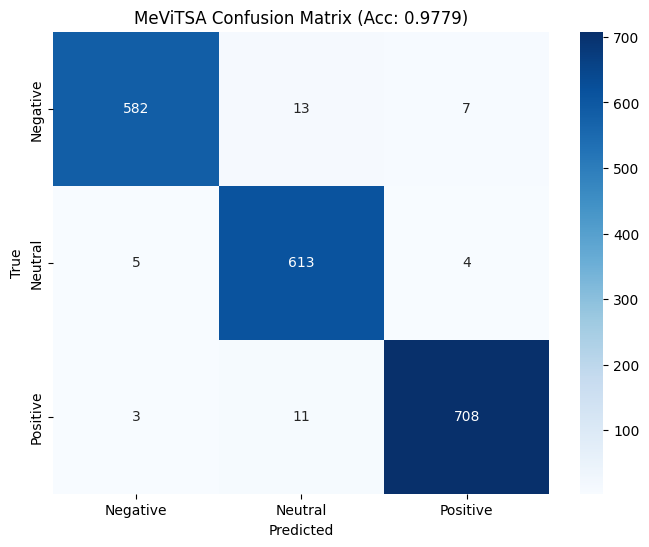

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(large_subset_enabled_results)
output_path = "mevitsa_large_subset_results_TEF1.csv"
df_results.to_csv(output_path, index=False)

acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("mevitsa_large_subset_TEF1__confusion_matrix.png")
plt.show()